# Multi-Scale Modeling of Transmembrane Transport Dynamics and Downstream Genetic Expression

This notebook demonstrates how to build, simulate, and compare multi-scale chemical reaction networks (CRNs) in BioCRNpyler integrated with cell-free expression machinery (`EnergyTxTlExtract`). The workflow explores four distinct levels of membrane transport complexity—**Secondary Active Symporter**, **Facilitated Carrier**, **Pore/Channel**, and **Simple Diffusion**—and evaluates their direct impact on downstream reporter gene expression (GFP).

## Paths

In [ ]:
# Get base directory for BioCRNpyler scripts
from pathlib import Path

# Packages
import biocrnpyler as bcp
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore") # Suppress warnings

# Directory
base_directory = Path.cwd().parents[1]
directory = base_directory / "biocrnpyler"

## Example

### Based DNA circuit and mixture

In [2]:
#Identify the compartments
internal = bcp.Compartment(name='cytoplasm')
membrane = bcp.Compartment(name='membrane')
external = bcp.Compartment(name='extracellular')

# Components
gfp_mat = bcp.Species('GFPm', material_type='protein')
reporter_assembly = bcp.DNAassembly(
    name="GFP",
    promoter='Strong',
    rbs = 'Strong',
    protein="GFP",
    compartment=internal
)

# Mixture
crn_dna= bcp.EnergyTxTlExtract(
    "symporter_mix",
    components=[reporter_assembly],
    compartment=internal
).compile_crn()

# DNA species and reactions + GFP maturation
rxn_gfp = bcp.Reaction.from_massaction(
    [crn_dna.species[9]],
    [gfp_mat],
    k_forward=1/(60*6.5)
)
atp = crn_dna.species[6]
dna_species = crn_dna.species
dna_rxns = crn_dna.reactions + [rxn_gfp]

### Isolated membrane mechanisms mixtures

In [ ]:
# Symporter
symporter = bcp.MembraneCarrier(
    membrane_carrier='IMP',
    substrate=atp,
    internal_compartment='cytoplasm',
    external_compartment='extracellular',
)
crn_symporter = bcp.Mixture(
    "symporter_mix",
    components=[symporter],
    mechanisms=
    {'transport': bcp.Transport_SecondaryActive_Symporter(
        driving_ion={'Na': '1:1'}
    )},
).compile_crn()

# Carrier
carrier = bcp.MembraneCarrier(
    membrane_carrier='IMP',
    substrate=atp,
    internal_compartment='cytoplasm',
    external_compartment='extracellular'
)
crn_carrier = bcp.Mixture(
    "carrier_mix",
    components=[carrier],
    mechanisms={'diffusion': bcp.Diffusion_Facilitated_Carrier()},
).compile_crn()

# Channel
channel = bcp.MembraneChannel(
    membrane_channel='IMP',
    substrate=atp,
    internal_compartment='cytoplasm',
    external_compartment='extracellular'
)
crn_channel = bcp.Mixture(
    "channel_crn",
    components=[channel],
    mechanisms={'diffusion': bcp.Diffusion_Facilitated_Channel()},
).compile_crn()

# Simple Diffusion
simple_diffusion = bcp.DiffusibleMolecule(
    substrate=atp,
    internal_compartment='cytoplasm',
    external_compartment='extracellular'
)
crn_diffusion = bcp.Mixture(
    "diffusion_crn",
    components=[simple_diffusion],
    mechanisms={'diffusion': bcp.Diffusion_Simple()},
).compile_crn()

# All models - update
models = [crn_symporter, crn_carrier, crn_channel, crn_diffusion]
for model in models:
    model.add_reactions(dna_rxns)
    model.add_species(dna_species)

### Simulation

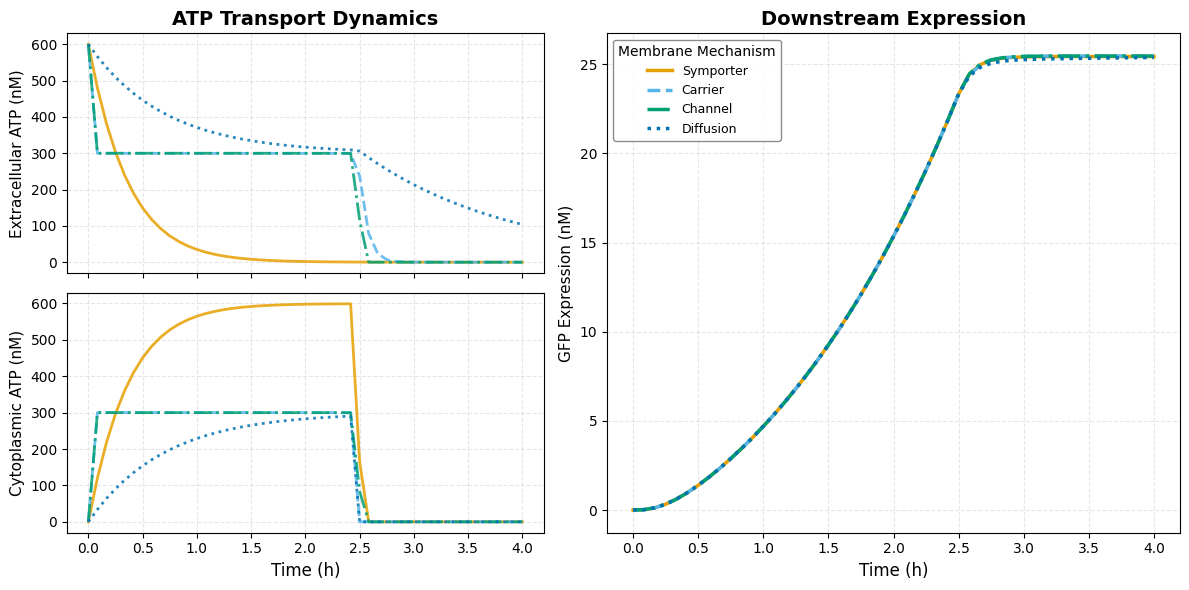

In [ ]:
# Simulate CRN
try:
    import matplotlib.gridspec as gridspec

    # Time
    Hours = 4
    step_size_seconds = 300  # 5 minutes in seconds
    timepoints = np.arange(0, (Hours * 3600) + 1, step_size_seconds)

    # Intial Conditions
    x0_true = {
        'protein_IMP_out': 0.5,
        'protein_IMP_in': 0.5, 'protein_IMP': 1,
        'metabolite_ATP_extracellular': 600,
        'metabolite_ATP_cytoplasm': 0,
        'Na_extracellular': 145000,
        'Na_cytoplasm': 15000,

        reporter_assembly.dna: 0.001,
        'metabolite_amino_acids_cytoplasm': 60000.0,
        'metabolite_Fuel_3PGA_cytoplasm': 30000.0,
        'metabolite_NTPs_cytoplasm': 3600.0,
        'protein_Ribo_cytoplasm': 10.0,
        'protein_RNAP_cytoplasm': 0.5,
        'protein_RNase_cytoplasm': 0.25
    }

    # Dictionary mapping model keys to their visual properties
    model_data = {
        'Symporter': {'model': crn_symporter, 'color': '#E69F00', 'gfp_style': '-'},
        'Carrier':   {'model': crn_carrier,   'color': '#56B4E9', 'gfp_style': '--'},
        'Channel':   {'model': crn_channel,   'color': '#009E73', 'gfp_style': '-.'},
        'Diffusion': {'model': crn_diffusion, 'color': '#0072B2', 'gfp_style': ':'}
    }

    # Grid setup
    fig = plt.figure(figsize=(12, 6))
    gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1.2])

    ax_atp_ext = fig.add_subplot(gs[0, 0])
    ax_atp_cyt = fig.add_subplot(gs[1, 0], sharex=ax_atp_ext)
    ax_gfp = fig.add_subplot(gs[:, 1])

    # Simulation & Plotting Loop using the Dictionary
    for name, props in model_data.items():
        model = props['model']
        color = props['color']
        line_style = props['gfp_style']

        # Simulate
        R = model.simulate_with_bioscrape_via_sbml(timepoints, initial_condition_dict=x0_true)

        if(R is not None):
            # Extracellular ATP
            ax_atp_ext.plot(
                timepoints / 3600, R['metabolite_ATP_extracellular'],
                linewidth=2, color=color, linestyle=line_style, alpha=0.85
            )
            # Cytoplasmic ATP
            ax_atp_cyt.plot(
                timepoints / 3600, R['metabolite_ATP_cytoplasm'],
                linewidth=2, color=color, linestyle=line_style, alpha=0.85
            )

            # GFPm
            ax_gfp.plot(
                timepoints / 3600, R['protein_GFPm'],
                linewidth=2.5, color=color, linestyle=line_style, label=name
            )

    # ATP Dynamics
    ax_atp_ext.set_title("ATP Transport Dynamics", fontsize=14, fontweight='bold')
    ax_atp_ext.set_ylabel("Extracellular ATP (nM)", fontsize=11)
    ax_atp_ext.tick_params(labelbottom=False)
    ax_atp_ext.grid(True, linestyle='--', alpha=0.3)

    ax_atp_cyt.set_xlabel("Time (h)", fontsize=12)
    ax_atp_cyt.set_ylabel("Cytoplasmic ATP (nM)", fontsize=11)
    ax_atp_cyt.grid(True, linestyle='--', alpha=0.3)

    # GFP matured
    ax_gfp.set_title("Downstream Expression", fontsize=14, fontweight='bold')
    ax_gfp.set_xlabel("Time (h)", fontsize=12)
    ax_gfp.set_ylabel("GFP Expression (nM)", fontsize=11)
    ax_gfp.grid(True, linestyle='--', alpha=0.3)

    # Legend inside top-left corner of phenotype plot
    ax_gfp.legend(
        title="Membrane Mechanism",
        title_fontsize='10',
        fontsize=9,
        loc='upper left',
        frameon=True,
        facecolor='white',
        framealpha=0.9,
        edgecolor='gray'
    )

    plt.tight_layout()
    # plt.savefig("fig_ATPnGFPexpression.svg")
    plt.show()
    
except ModuleNotFoundError:
    print('please install the plotting libraries: pip install biocrnpyler[all]')